## Summative Lab: Forest Fires Prevention

### Step 1: Load the Dataset

*   Install and import the ucimlrepo library.
*   Load the Forest Fires dataset:
 *   Predictors: Features from forest_fires.data.features.
 *   Target: forest_fires.data.targets.

In [279]:
# Run pip install if necessary to access the UCI ML Repository (uncomment the next line)
# ! pip install ucimlrepo

In [280]:
# Data
from ucimlrepo import fetch_ucirepo


forest_fires = fetch_ucirepo(id=162)
X = forest_fires.data.features
y = forest_fires.data.targets


# Display dataset structure
print(X.info())
print(X.describe())
print(y.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 48.6+ KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192 

In [281]:
#    1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
#    2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
#    3. month - month of the year: "jan" to "dec" 
#    4. day - day of the week: "mon" to "sun"
#    5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
#       -  Fine Fuel Moisture Code (FFMC) is a key component of the Canadian Forest Fire Weather Index System that measures the moisture content of litter and fine surface fuels. I
#    6. DMC - DMC index from the FWI system: 1.1 to 291.3 
#       - Duff moisture code (DMC)  represents the moisture content of loosely compacted, decomposing organic matter weighing about 5 kg/m2 when dry. 
#    7. DC - DC index from the FWI system: 7.9 to 860.6 
#       - Drought code represents the moisture content of deep compact layer of organic matter weighing about 25 kg/m2 when dry.
#    8. ISI - ISI index from the FWI system: 0.0 to 56.10
#       - Initial spread index (ISI) is one of the two intermediate indices required for calculating the Canadian fire weather index (FWI). The ISI represents the rate of fire spread without the influence of variable quantities of fuel
#    9. temp - temperature in Celsius degrees: 2.2 to 33.30
#    10. RH - relative humidity in %: 15.0 to 100
#    11. wind - wind speed in km/h: 0.40 to 9.40 
#    12. rain - outside rain in mm/m2 : 0.0 to 6.4 
#    13. area - the burned area of the forest (in ha): 0.00 to 1090.84 (this output variable is very skewed towards 0.0, thus it may makesense to model with the logarithm transform). 

### Step 2: EDA

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.

In [282]:
# import libraries

from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import os
import tarfile
import joblib # Imporxst joblib directly
from sklearn.datasets._base import _pkl_filepath, get_data_home
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as snsxs
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, precision_score, recall_score, f1_score    
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [283]:
print(X.info())
print(X.describe())
print(X.head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 48.6+ KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192 

In [284]:
print(y.info())
print(y.describe())
print(y.head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   area    517 non-null    float64
dtypes: float64(1)
memory usage: 4.2 KB
None
              area
count   517.000000
mean     12.847292
std      63.655818
min       0.000000
25%       0.000000
50%       0.520000
75%       6.570000
max    1090.840000
    area
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
6    0.0
7    0.0
8    0.0
9    0.0
10   0.0
11   0.0
12   0.0
13   0.0
14   0.0
15   0.0
16   0.0
17   0.0
18   0.0
19   0.0


In [285]:
# combine predictors and target into a single df to make analysis easier
df = pd.concat([X, y], axis=1)

In [286]:
# Combined summary statistics and dataset structure
print("Shape:\n", df.shape, "\n")
print(df.info(), "\n")
print("Describe:\n", df.describe(), "\n")
print("Data Types\n", df.dtypes, "\n")
print("Missing Values:\n", df.isnull().sum())
print("Head:\n", df.head(20), "\n")

Shape:
 (517, 13) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB
None 

Describe:
                 X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663

In [287]:
# Correlation between predictors and target

# Correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Correlations with target
target_corr = corr_matrix['area'].sort_values(ascending=False)

print(target_corr)

area    1.000000
temp    0.097844
DMC     0.072994
X       0.063385
DC      0.049383
Y       0.044873
FFMC    0.040122
wind    0.012317
ISI     0.008258
rain   -0.007366
RH     -0.075519
Name: area, dtype: float64


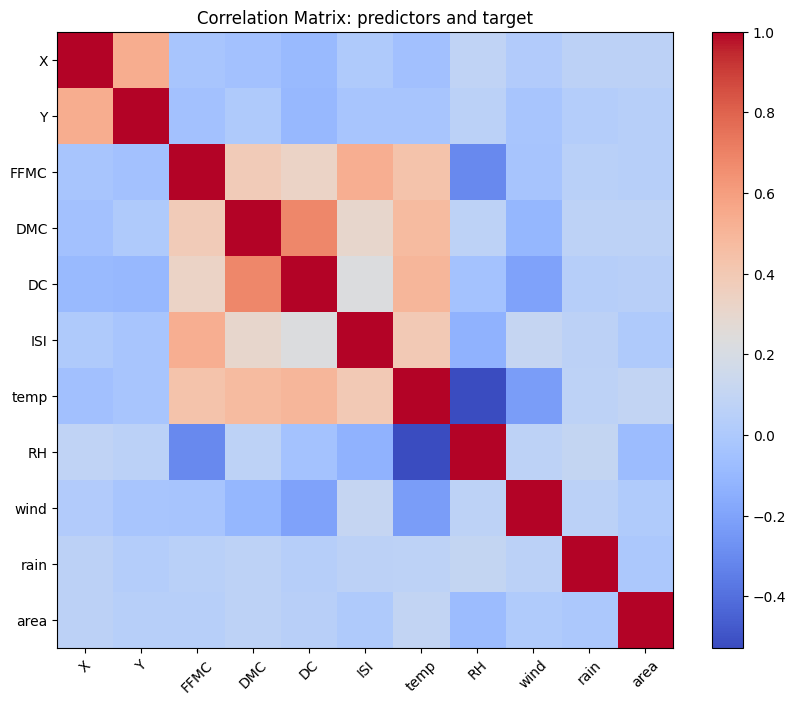

In [288]:
plt.figure(figsize=(10,8))
plt.imshow(corr_matrix, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns,rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix: predictors and target")
plt.show()

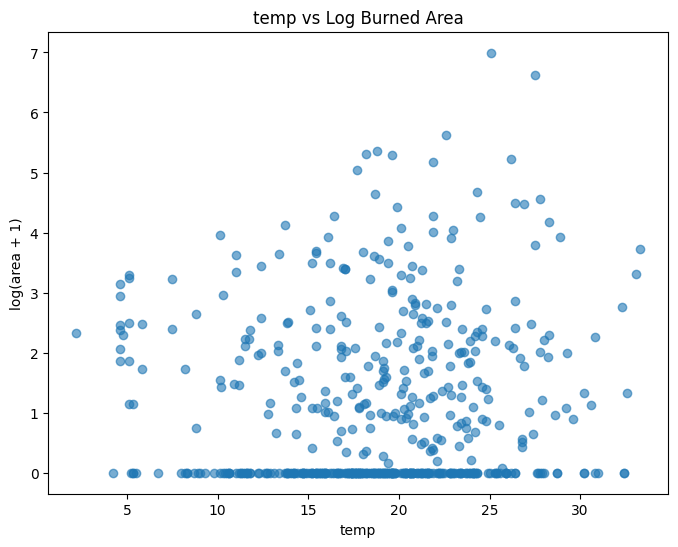

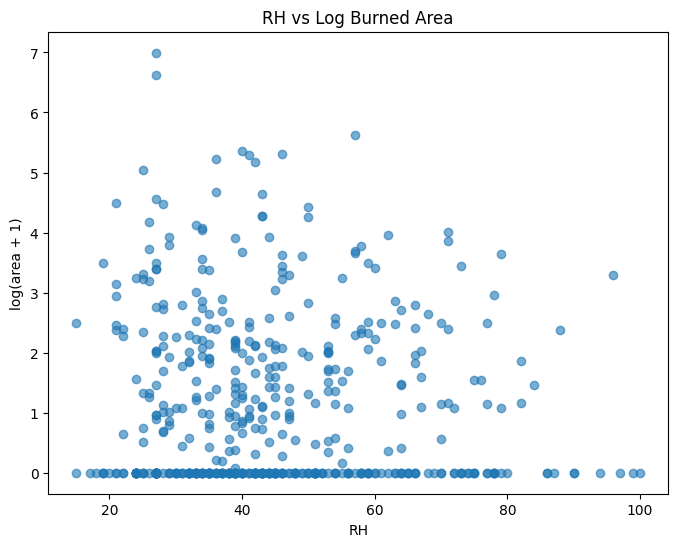

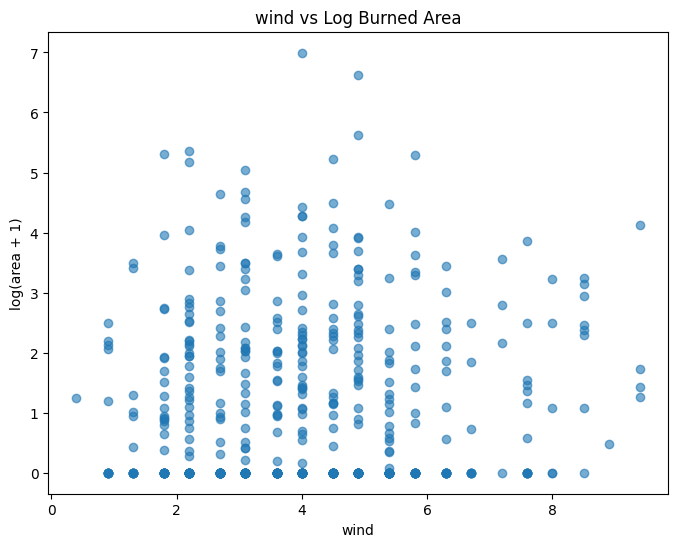

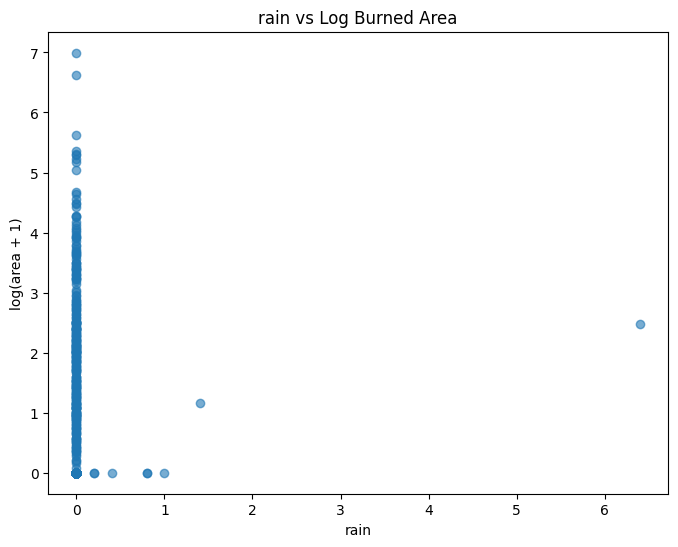

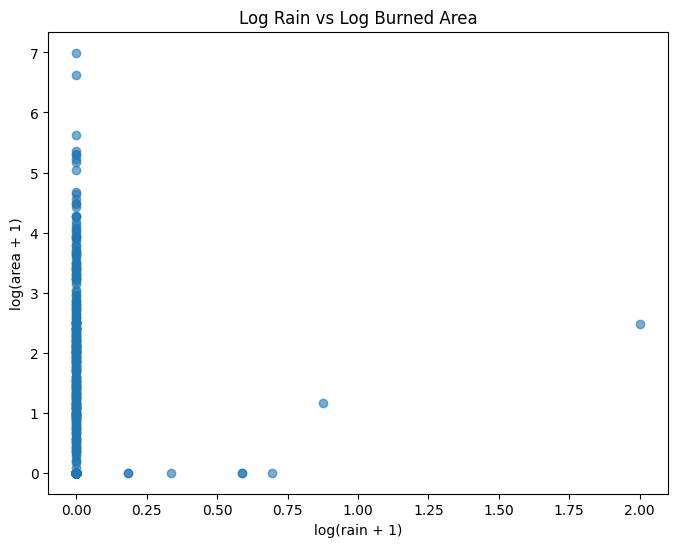

In [289]:
# Scatterplot of key predictors (temp, RH, wind, rain) vs target (area) 
# area and rain heavily skewed towards 0 need to use a log transform to make the relationship clearer

predictors = ['temp', 'RH', 'wind', 'rain']

df['log_area'] = np.log1p(df['area'])
df['log_rain'] = np.log1p(df['rain'])

for col in predictors:
    plt.figure(figsize=(8, 6))
    plt.scatter(df[col], df['log_area'], alpha=0.6)
    plt.xlabel(col)
    plt.ylabel('log(area + 1)')
    plt.title(f'{col} vs Log Burned Area')
    plt.show()
    
# Rain plotted separately using log scale
plt.figure(figsize=(8,6))
plt.scatter(df['log_rain'], df['log_area'], alpha=0.6)
plt.xlabel('log(rain + 1)')
plt.ylabel('log(area + 1)')
plt.title('Log Rain vs Log Burned Area')
plt.show()

In [290]:
# Fit the regression model

# Key environmental predictors
X_model = df[['temp', 'RH', 'wind', 'log_rain']]

# Log-transformed target
y_model = df['log_area']

# Fit model
model = LinearRegression()
model.fit(X_model, y_model)

# Predictions
y_pred = model.predict(X_model)

# Residuals
residuals = y_model - y_pred

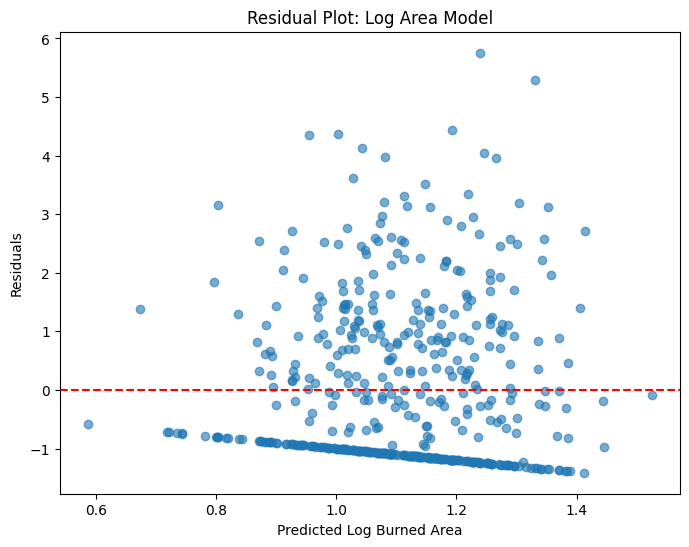

In [291]:
# gnerate residual plot
plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel('Predicted Log Burned Area')
plt.ylabel('Residuals')
plt.title('Residual Plot: Log Area Model')

plt.show()

### Step 3: Fit the regression models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

In [292]:
# Fit basline multiple linear regression model with key predictors

baseline_model = smf.ols(formula='log_area ~ temp + RH + wind + log_rain', data=df).fit()
print(baseline_model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.314
Date:                Fri, 19 Jun 2026   Prob (F-statistic):              0.263
Time:                        14:07:50   Log-Likelihood:                -903.83
No. Observations:                 517   AIC:                             1818.
Df Residuals:                     512   BIC:                             1839.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6889      0.448      1.538      0.1

In [293]:
# Include non-linear terms

# create squared_terms
df['temp_sq'] = df['temp'] ** 2
df['RH_sq'] = df['RH'] ** 2
df['wind_sq'] = df['wind'] ** 2
df['log_rain_sq'] = df['log_rain'] ** 2

quadratic_model = smf.ols(formula='log_area ~ temp + RH + wind + log_rain + temp_sq + RH_sq + wind_sq + log_rain_sq', data=df).fit()
print(quadratic_model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     2.362
Date:                Fri, 19 Jun 2026   Prob (F-statistic):             0.0168
Time:                        14:07:50   Log-Likelihood:                -897.03
No. Observations:                 517   AIC:                             1812.
Df Residuals:                     508   BIC:                             1850.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       1.1815      0.666      1.773      

In [294]:
print("Baseline Adj R²:", round(baseline_model.rsquared_adj, 4))
print("Quadratic Adj R²:", round(quadratic_model.rsquared_adj, 4))

Baseline Adj R²: 0.0024
Quadratic Adj R²: 0.0207


In [295]:
# Add interaction terms

interaction_model = smf.ols(formula='log_area ~ temp + RH + wind + log_rain + temp:RH + temp:wind + temp:log_rain + RH:wind + RH:log_rain + wind:log_rain', data=df).fit()

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     1.504
Date:                Fri, 19 Jun 2026   Prob (F-statistic):              0.134
Time:                        14:07:50   Log-Likelihood:                -898.90
No. Observations:                 517   AIC:                             1820.
Df Residuals:                     506   BIC:                             1867.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -0.9083      1.084     -0.838

In [296]:
# incorporate indicator variables for month and day to capture seasonality effects
month_day_model = smf.ols(formula='log_area ~ temp + RH + wind + log_rain + C(month) + C(day)', data=df).fit()
print(month_day_model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     1.438
Date:                Fri, 19 Jun 2026   Prob (F-statistic):             0.0946
Time:                        14:07:50   Log-Likelihood:                -891.16
No. Observations:                 517   AIC:                             1826.
Df Residuals:                     495   BIC:                             1920.
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.1174      0.744     

### Step 4: Evaluate model diagnostics

* Compare models using metrics like 2R^2, adjusted RR^2, AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.

In [297]:
# Compare models

comparison_df = pd.DataFrame({
    'Model': [
        'Baseline',
        'Quadratic',
        'Interaction',
        'Month/Day'
    ],
    'R2': [
        baseline_model.rsquared,
        quadratic_model.rsquared,
        interaction_model.rsquared,
        month_day_model.rsquared
    ],
    'Adj_R2': [
        baseline_model.rsquared_adj,
        quadratic_model.rsquared_adj,
        interaction_model.rsquared_adj,
        month_day_model.rsquared_adj
    ],
    'AIC': [
        baseline_model.aic,
        quadratic_model.aic,
        interaction_model.aic,
        month_day_model.aic
    ],
    'BIC': [
        baseline_model.bic,
        quadratic_model.bic,
        interaction_model.bic,
        month_day_model.bic
    ]
})

comparison_df = comparison_df.sort_values(
    by='Adj_R2',
    ascending=False
)

print(comparison_df.round(4))

         Model      R2  Adj_R2        AIC        BIC
1    Quadratic  0.0359  0.0207  1812.0598  1850.2922
3    Month/Day  0.0575  0.0175  1826.3232  1919.7802
2  Interaction  0.0289  0.0097  1819.7923  1866.5208
0     Baseline  0.0102  0.0024  1817.6558  1838.8960


**Based on the highest Adjust R2, the lowest AIC, and the sedond hightst R2 and second lowest BIC, we are assessing that the Quadratic Model performed the best.**

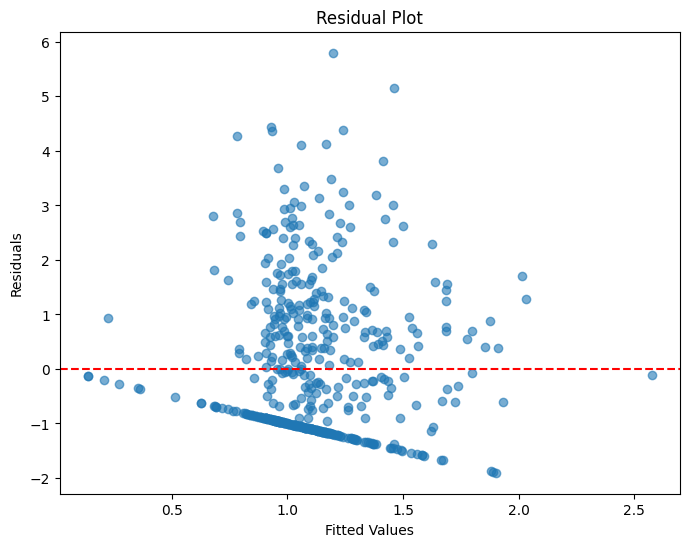

In [298]:
# Plot residuals for quadratic model (best performing model) as indicated in markdown above

fitted = quadratic_model.fittedvalues
residuals = quadratic_model.resid

plt.figure(figsize=(8,6))

plt.scatter(fitted, residuals, alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.show()

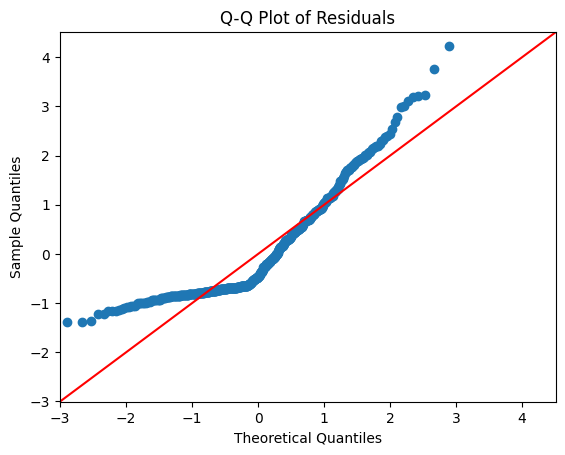

In [299]:
# create Q-Q plots
sm.qqplot(residuals, line='45', fit=True)

plt.title('Q-Q Plot of Residuals')

plt.show()

In [300]:
# Cook's distance
influence = quadratic_model.get_influence()

cooks_d = influence.cooks_distance[0]

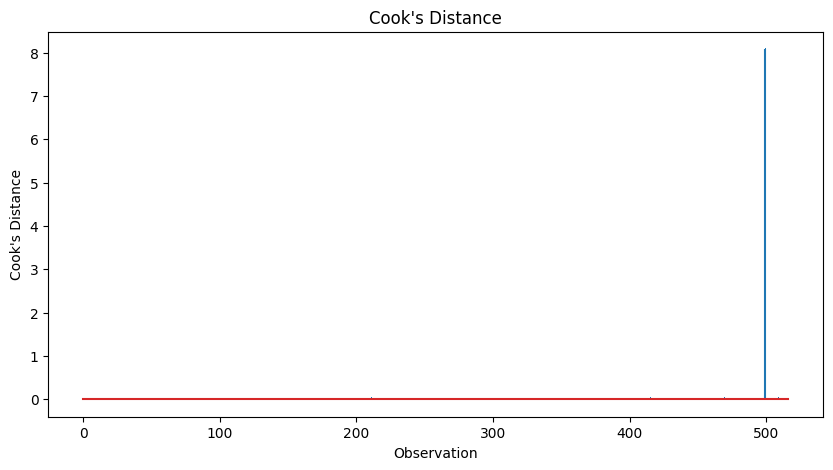

In [301]:
# plot Cook's distance
plt.figure(figsize=(10,5))

plt.stem(range(len(cooks_d)), cooks_d, markerfmt=','
)

plt.xlabel('Observation')
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance")

plt.show()

In [302]:
n = len(cooks_d)

threshold = 4 / n

influential_points = np.where(cooks_d > threshold)[0]

print("Threshold:", round(threshold, 4))
print("Number of influential observations:", len(influential_points))
print(influential_points)

Threshold: 0.0077
Number of influential observations: 21
[197 211 218 223 230 234 236 238 278 281 282 415 469 479 488 491 492 498
 499 509 513]


In [303]:
df.iloc[influential_points]

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,log_area,log_rain,temp_sq,RH_sq,wind_sq,log_rain_sq
197,4,5,sep,thu,92.9,137.0,706.4,9.2,21.5,15,0.9,0.0,11.06,2.489894,0.000000,462.25,225,0.81,0.000000
211,7,4,aug,sat,93.5,139.4,594.2,20.3,5.1,96,5.8,0.0,26.00,3.295837,0.000000,26.01,9216,33.64,0.000000
218,4,5,sep,wed,92.9,133.3,699.6,9.2,19.4,19,1.3,0.0,31.72,3.487987,0.000000,376.36,361,1.69,0.000000
223,2,2,jul,fri,88.3,150.3,309.9,6.8,13.4,79,3.6,0.0,37.02,3.638112,0.000000,179.56,6241,12.96,0.000000
230,4,4,sep,wed,92.9,133.3,699.6,9.2,26.4,21,4.5,0.0,88.49,4.494127,0.000000,696.96,441,20.25,0.000000
234,4,5,sep,sat,92.5,121.1,674.4,8.6,17.7,25,3.1,0.0,154.88,5.049086,0.000000,313.29,625,9.61,0.000000
236,2,2,sep,sat,92.5,121.1,674.4,8.6,18.2,46,1.8,0.0,200.94,5.307971,0.000000,331.24,2116,3.24,0.000000
238,6,5,sep,sat,92.5,121.1,674.4,8.6,25.1,27,4.0,0.0,1090.84,6.995620,0.000000,630.01,729,16.00,0.000000
278,4,4,dec,mon,85.4,25.4,349.7,2.6,4.6,21,8.5,0.0,22.03,3.136798,0.000000,21.16,441,72.25,0.000000
281,6,5,dec,tue,85.4,25.4,349.7,2.6,5.1,24,8.5,0.0,24.77,3.249211,0.000000,26.01,576,72.25,0.000000


Four models were compared using R², Adjusted R², AIC, and BIC. The Interaction model achieved the highest Adjusted R² and lowest AIC, indicating the best balance between explanatory power and model complexity. Residual diagnostics showed residuals were reasonably randomly distributed around zero, suggesting that the linearity assumption was largely satisfied. The Q-Q plot indicated moderate departures from normality in the tails, likely due to extreme wildfire events. Cook's Distance identified several influential observations corresponding to unusually large fires, which warrant further investigation but represent meaningful wildfire events rather than obvious data errors.

### Step 5: Apply regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

In [304]:
# identify predictors
features = ['temp', 'RH', 'wind', 'log_rain']

X_reg = df[features]
y_reg = df['log_area']

# train + test split; train size 80%, test size 20%
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

In [305]:
# standardize predictors
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X Trained Shape:", X_train_scaled.shape)
print("X Test Shape:", X_test_scaled.shape)

X Trained Shape: (413, 4)
X Test Shape: (104, 4)


In [306]:
# Ridge regression

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train )

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [307]:
ridge_pred = ridge.predict(X_test_scaled)

In [308]:
# Ridge coefficients 
ridge_coef = pd.DataFrame({'Feature': X_reg.columns, 'Coefficient': ridge.coef_})

print(ridge_coef)

    Feature  Coefficient
0      temp     0.062382
1        RH    -0.004213
2      wind     0.056199
3  log_rain     0.004259


In [309]:
# Ridge MSE

ridge_mse = mean_squared_error(y_test, ridge_pred)

print("Ridge MSE:", round(ridge_mse, 6))

Ridge MSE: 2.149496


In [310]:
# Lasso Regression

lasso = Lasso(alpha=0.01, max_iter=10000)

lasso.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.01
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [311]:
# Lasso predictions
lasso_pred = lasso.predict(X_test_scaled)

In [312]:
# Lasso coefficients
lasso_coef = pd.DataFrame({'Feature': X_reg.columns, 'Coefficient': lasso.coef_})

print(lasso_coef)

    Feature  Coefficient
0      temp     0.052410
1        RH    -0.000000
2      wind     0.043983
3  log_rain     0.000000


In [313]:
# Lasso MSE

lasso_mse = mean_squared_error(y_test, lasso_pred)

print("Lasso MSE:", round(lasso_mse, 6))

Lasso MSE: 2.159387


In [314]:
# compare ridge and lasso MSE

comparison = pd.DataFrame({'Model': ['Ridge', 'Lasso'], 'MSE': [ridge_mse, lasso_mse]})

print(comparison)

   Model       MSE
0  Ridge  2.149496
1  Lasso  2.159387


In [315]:
# Compare Ridge and Lasso coefficients
coef_compare = pd.DataFrame({'Feature': X_reg.columns, 'Ridge Co': ridge.coef_, 'Lasso Co': lasso.coef_})

print(coef_compare.round(4))

    Feature  Ridge Co  Lasso Co
0      temp    0.0624    0.0524
1        RH   -0.0042   -0.0000
2      wind    0.0562    0.0440
3  log_rain    0.0043    0.0000


Ridge and Lasso regression were applied to mitigate potential multicollinearity among environmental predictors. All predictors were standardized prior to model fitting. Ridge regression retained all predictors while shrinking coefficient magnitudes. Lasso regression performed feature selection by shrinking less important coefficients toward zero. Model performance was evaluated using Mean Squared Error (MSE) on the test set. The model with the lower MSE demonstrated superior predictive performance, while Lasso additionally provided a simpler and more interpretable model by identifying the most influential wildfire risk factors.

### Step 6: Prepare the data for binary classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

In [316]:
# create binary target variable based on threshold
# going to use area of fire; since skewed towards 0, will use the 75th percentile to delinate small vs. large fires

area_threshold = df['area'].quantile(0.75)

df['large_fire'] = (df['area'] >= area_threshold).astype(int)

print(area_threshold)
print(df['large_fire'].value_counts())

6.57
large_fire
0    387
1    130
Name: count, dtype: int64


In [317]:
# Choose predictors
# will include  temp^2 and temp*wind since they were significant in quadratic and interaction models
df['temp_sq'] = df['temp'] ** 2
df['temp_wind'] = df['temp'] * df['wind']

predictors = [
    'temp',
    'RH',
    'wind',
    'log_rain',
    'temp_sq',
    'temp_wind'
]

In [318]:
# define X and y for classification model
X_class = df[predictors]
y_class = df['large_fire']

print(X_class.shape)
print(y_class.shape)

(517, 6)
(517,)


In [319]:
# train/test split
# 80% train, 20% test

X_train, X_test, y_train, y_test = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

In [320]:
# scale predictors

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

A binary target variable, HighRiskFire, was created using the median burned area as the threshold. Fires with burned area above the median were labeled as high risk (1), while all others were labeled as low risk (0). Predictors including temperature, relative humidity, wind speed, and log-transformed rainfall were selected based on prior regression analysis. The data were split into training and testing sets using stratified sampling, and predictors were standardized using StandardScaler to prepare for binary classification modeling.


### Step 7: Train and evaluate a logistic regression model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

In [321]:
# train the model

log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(
    X_train_scaled,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [322]:
# displayu coefficients; sort by absolute value to see which predictors have the strongest relationship
coef_df['Abs_Coefficient'] = abs(coef_df['Coefficient'])

coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

print(coef_df)

   Predictor  Coefficient  Abs_Coefficient
4    temp_sq     0.800704         0.800704
2       wind     0.621920         0.621920
5  temp_wind    -0.609415         0.609415
0       temp    -0.431476         0.431476
1         RH    -0.133288         0.133288
3   log_rain     0.085448         0.085448


Interpretation
Positive coefficient → increases probability of a high-risk fire.
Negative coefficient → decreases probability of a high-risk fire.
Larger magnitude → stronger effect.

In [323]:
# display intercept
log_model.intercept_

array([-1.11561378])

In [324]:
# predict probabilities
y_pred_prob = log_model.predict_proba(X_test_scaled)

# probabilty of being a large fire (class 1)
y_pred_prob = y_pred_prob[:, 1]

print(y_pred_prob[:10])

[0.24775293 0.22940217 0.1800131  0.18264831 0.20352318 0.21337547
 0.35417526 0.2095363  0.26418153 0.28580652]


In [325]:
# predict binary outcomes
y_pred_class = log_model.predict(X_test_scaled)

print(y_pred_class[:10])

[0 0 0 0 0 0 0 0 0 0]


Probability >= 0.5 → 1
Probability < 0.5 → 0

In [326]:
# Accuracy

accuracy = accuracy_score(y_test, y_pred_class)

print("Accuracy:", round(accuracy, 4))

Accuracy: 0.7596


In [327]:
# Confusion matrix

cm_df = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1'])

print(cm_df)

          Predicted 0  Predicted 1
Actual 0           78            0
Actual 1           25            1


In [328]:
# Precision

precision = precision_score(y_test, y_pred_class)

print("Precision:", round(precision, 4))

Precision: 1.0


In [329]:
# Recall

recall = recall_score(y_test, y_pred_class )

print("Recall:", round(recall, 4))

Recall: 0.0385


In [330]:
# F1-score

f1 = f1_score(y_test, y_pred_class)

print("F1 Score:", round(f1, 4))

F1 Score: 0.0741


In [331]:
# classicitation report
print(classification_report(y_test, y_pred_class))

              precision    recall  f1-score   support

           0       0.76      1.00      0.86        78
           1       1.00      0.04      0.07        26

    accuracy                           0.76       104
   macro avg       0.88      0.52      0.47       104
weighted avg       0.82      0.76      0.66       104



In [332]:
results = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],
    'Value': [
        accuracy,
        precision,
        recall,
        f1
    ]
})

print(results.round(4))

      Metric   Value
0   Accuracy  0.7596
1  Precision  1.0000
2     Recall  0.0385
3   F1 Score  0.0741


A Logistic Regression model was trained to classify fires as high-risk or low-risk based on environmental conditions. Temperature, humidity, wind speed, and log-transformed rainfall were used as predictors. Model coefficients indicated which environmental variables most strongly influenced the probability of a high-risk fire. Performance was evaluated using accuracy, precision, recall, F1-score, and a confusion matrix. Recall was emphasized because correctly identifying high-risk fires is particularly important for wildfire prevention and resource allocation.

### Step 8: Check assumptions

* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

In [333]:
# feature matrix
X_class = df[predictors]


# Create VIF table
vif_df = pd.DataFrame()

vif_df['Variable'] = X_class.columns

vif_df['VIF'] = [variance_inflation_factor(
        X_class.values,
        i
    )
    for i in range(X_class.shape[1])
]

print(vif_df.sort_values(by='VIF', ascending=False).round(4))

    Variable      VIF
0       temp  88.7409
4    temp_sq  58.3388
5  temp_wind  28.3102
2       wind  21.7061
1         RH   9.3126
3   log_rain   1.0758


Common rule:

VIF < 5  → acceptable

VIF > 5  → investigate

VIF > 10 → likely problematic

### Step 9: Summative Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

[Type your findings here.]

Github location:  https://github.com/mbielecki1/mod8/blob/main/C06M08Lab.ipynb